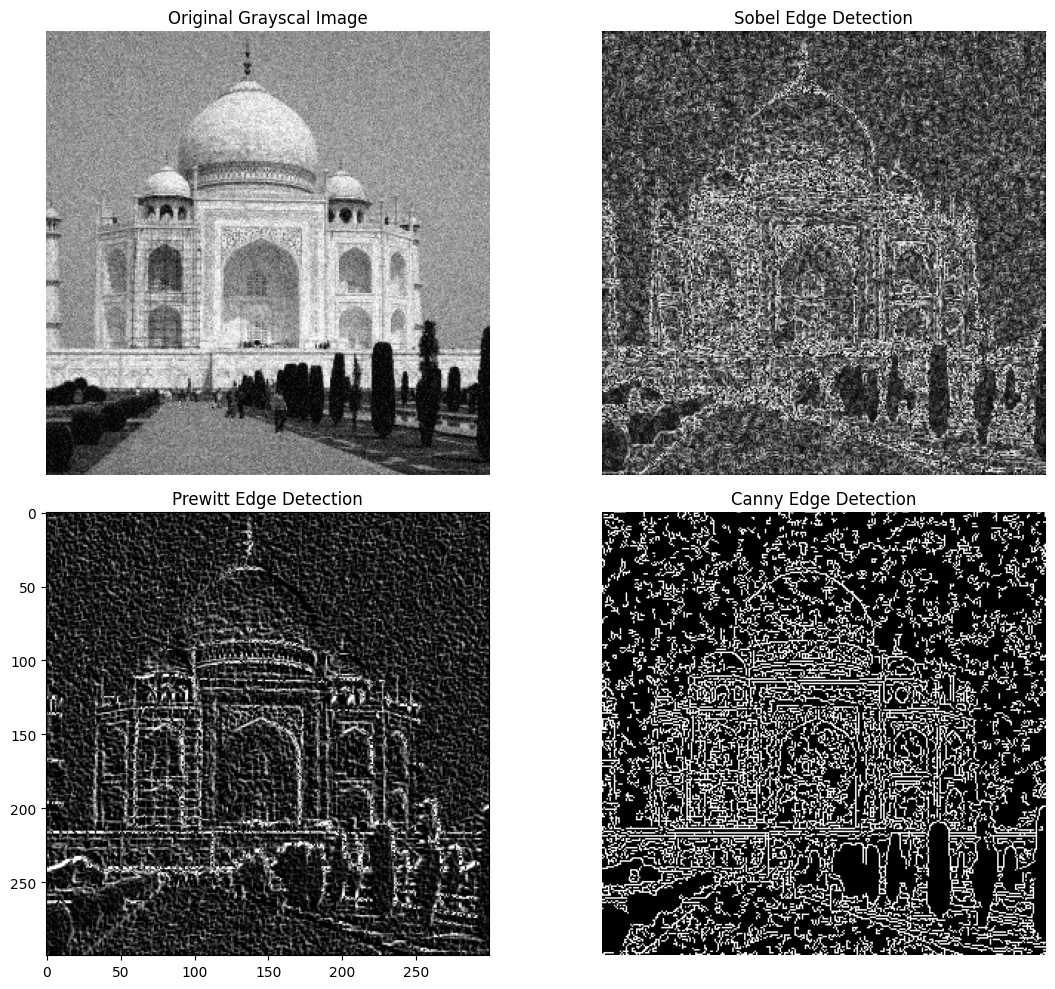

In [ ]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

def show_comparsion(original,sobel,perwitt, canny):
  plt.figure(figsize=(12,10))

  plt.subplot(2,2,1)
  plt.imshow(original,cmap='gray')
  plt.title('Original Grayscal Image')
  plt.axis('off')

  plt.subplot(2,2,2)
  plt.imshow(sobel,cmap='gray')
  plt.title('Sobel Edge Detection')
  plt.axis('off')

  plt.subplot(2,2,3)
  plt.imshow(perwitt,cmap='gray')
  plt.title('Prewitt Edge Detection')

  plt.subplot(2,2,4)
  plt.imshow(canny, cmap='gray')
  plt.title("Canny Edge Detection")
  plt.axis('off')
  plt.axis('off')

  plt.tight_layout()
  plt.show()

img=cv2.imread('img.jpg',0)
if img is None:
  print('Error: Image not found')

else:
  sobelx=cv2.Sobel(img,cv2.CV_64F,1,0,ksize=3)
  sobely=cv2.Sobel(img,cv2.CV_64F,0,1,ksize=3)
  sobel_combained = cv2.magnitude(sobelx,sobely)

  kernelx=np.array([[1,1,1],[0,0,0],[-1,-1,-1]])
  kernely=np.array([[-1,0,1],[-1,0,1],[-1,0,1]])

  prewittx=cv2.filter2D(img,-1,kernelx)
  prewitty=cv2.filter2D(img,-1,kernely)
  prewitt_combined=prewittx+prewitty

  canny = cv2.Canny(img, 100, 200) # Example thresholds, these can be tuned

  show_comparsion(img,np.uint8(np.absolute(sobel_combained)),prewitt_combined, canny)